In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import tensorflow as tf # type: ignore
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from meridian.model import model, adstock_hill
from meridian.analysis import visualizer, analyzer

In [3]:
home_dir = '/Users/mariappan.subramanian/Library/CloudStorage/OneDrive-TheTradeDesk/MMM/BudgetOptimizer'
model_path = f'{home_dir}/model_objects/champ/'
model_name = '0_FINAL_cpm_weighted_by_working_spend_informative_national_False_ALDI_US_Starcom.pkl'

In [13]:
def get_geo_weighted_media_data(media_transformed, weights):
  raw_media_gtm = tf.convert_to_tensor(weights, dtype=media_transformed.dtype)
  media_times_transformed_tm = tf.reduce_sum(tf.multiply(raw_media_gtm, media_transformed), axis=0)  # (time, channel)
  raw_media_sum_tm = tf.reduce_sum(raw_media_gtm, axis=0)  # (time, channel)
  return tf.math.divide_no_nan(media_times_transformed_tm, raw_media_sum_tm)

,media_channel,alpha,ec,slope
0,TV,0.790537,0.680619,1.040953
1,Display,0.226074,3.456842,0.750044
2,Video,0.225401,1.339701,1.335165


,media_channel,media_scaled_sum,adstocked_media_sum,saturated_media_sum
0,TV,2729.818848,2632.063965,1239.695557
1,Display,2487.877686,2483.552490,617.113708
2,Video,3292.503662,3286.960449,913.626343


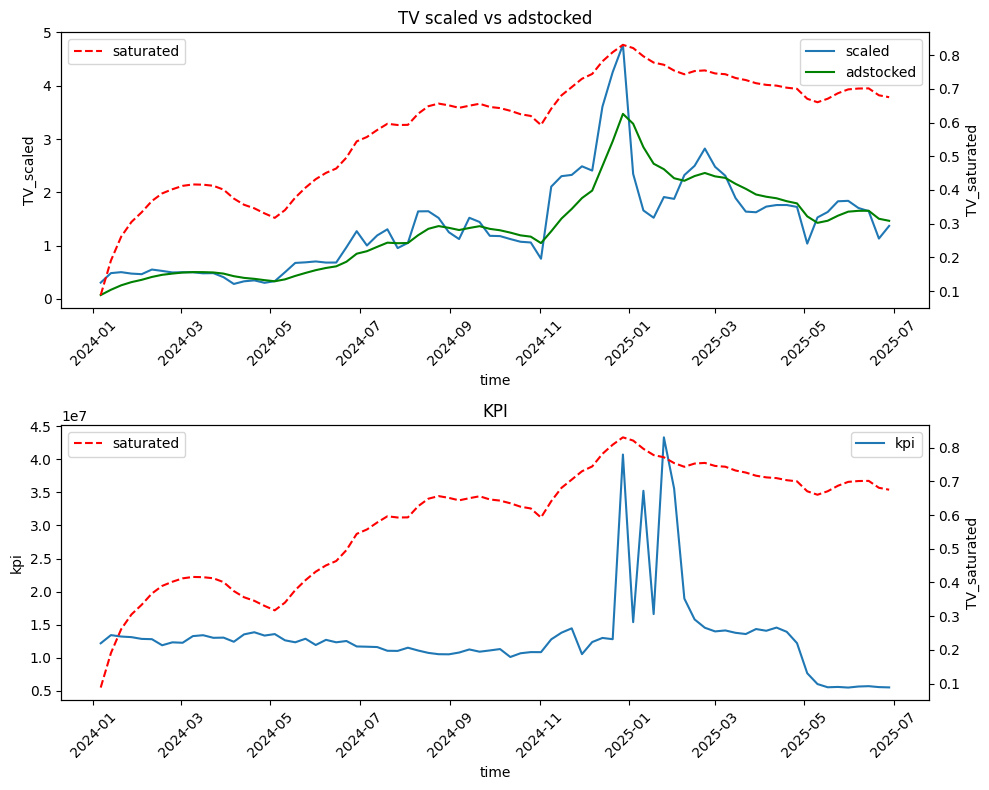

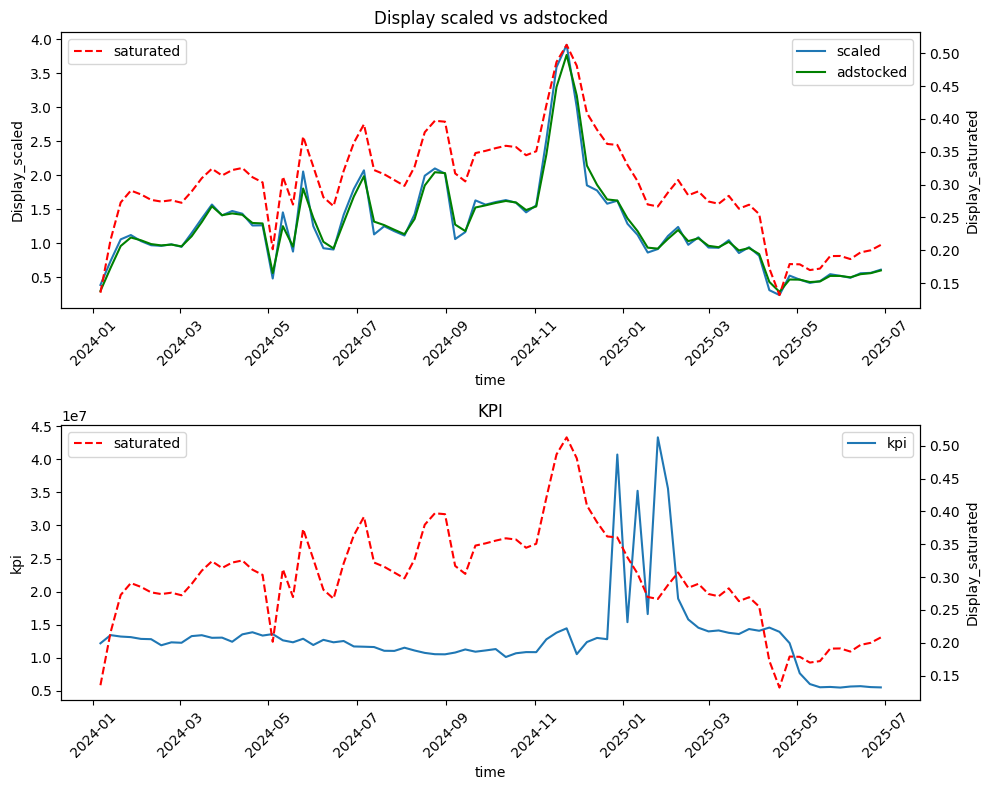

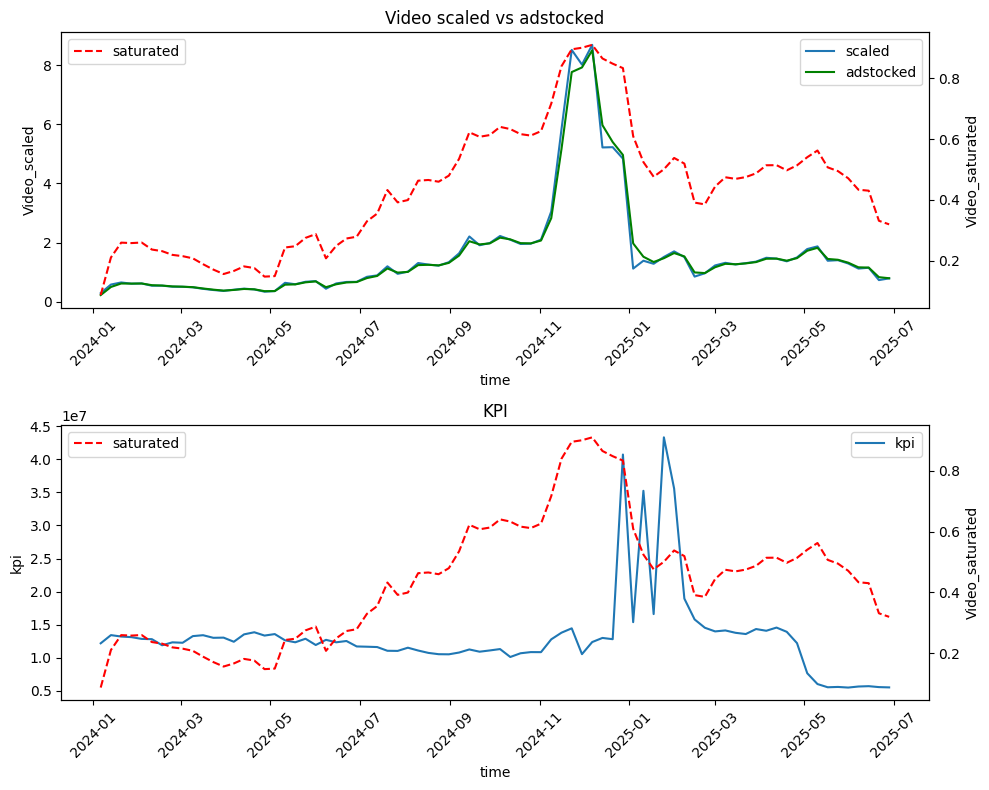

In [24]:
from meridian.mpa.plot_media_transformations import ExportMediaTransformations

mmm = model.load_mmm(f'{model_path}/{model_name}')
export_media_transformations = ExportMediaTransformations(mmm)
display(export_media_transformations.media_parameters_df)
display(export_media_transformations.media_sum_to_debug_df)
export_media_transformations.plot_media_journey_all()

In [22]:
export_media_transformations.media_trans_journey_df.head()

,time,TV_scaled,Display_scaled,Video_scaled,TV_adstocked,Display_adstocked,Video_adstocked,TV_saturated,Display_saturated,Video_saturated,kpi
0,2024-01-06,0.305423,0.389324,0.294055,0.072747,0.301308,0.227775,0.088324,0.135303,0.086660,12202838.0
1,2024-01-13,0.484356,0.741023,0.582722,0.172172,0.640178,0.501315,0.190768,0.215823,0.210492,13438686.0
2,2024-01-20,0.502564,1.059812,0.653927,0.255640,0.961923,0.618141,0.261526,0.272772,0.259333,13223137.0
3,2024-01-27,0.475405,1.123229,0.613122,0.315366,1.086721,0.614315,0.305126,0.290878,0.257864,13133472.0
4,2024-02-03,0.464491,1.034118,0.620421,0.358414,1.046066,0.618606,0.333882,0.285005,0.259683,12867219.0


In [14]:
export_media_transformations.media_trans_journey_df

,time,TV_scaled,Display_scaled,Video_scaled,TV_adstocked,Display_adstocked,Video_adstocked,TV_saturated,Display_saturated,Video_saturated
0,2024-01-06,0.305423,0.389324,0.294055,0.072747,0.301308,0.227775,0.088324,0.135303,0.086660
1,2024-01-13,0.484356,0.741023,0.582722,0.172172,0.640178,0.501315,0.190768,0.215823,0.210492
2,2024-01-20,0.502564,1.059812,0.653927,0.255640,0.961923,0.618141,0.261526,0.272772,0.259333
3,2024-01-27,0.475405,1.123229,0.613122,0.315366,1.086721,0.614315,0.305126,0.290878,0.257864
4,2024-02-03,0.464491,1.034118,0.620421,0.358414,1.046066,0.618606,0.333882,0.285005,0.259683
...,...,...,...,...,...,...,...,...,...,...
73,2025-05-31,1.840136,0.523152,1.295172,1.637218,0.522259,1.322299,0.698460,0.191293,0.471260
74,2025-06-07,1.706066,0.495383,1.122628,1.652833,0.501821,1.165198,0.700988,0.186551,0.433603
75,2025-06-14,1.646945,0.561430,1.151085,1.654414,0.547968,1.156618,0.701448,0.196712,0.430444
76,2025-06-21,1.132443,0.567211,0.733596,1.504076,0.562644,0.832268,0.680906,0.199874,0.331253


In [7]:

# Load the model
mmm = model.load_mmm(f'{model_path}/{model_name}')

# Get the parameters
posterior = mmm.inference_data.posterior
alpha_m_xr = posterior.alpha_m.median(dim=['chain', 'draw'])
ec_m_xr = posterior.ec_m.median(dim=['chain', 'draw'])
slope_m_xr = posterior.slope_m.median(dim=['chain', 'draw'])

# Get the scaled media data
media_scaled = mmm.media_tensors.media_scaled
media_scaled_tm = ExportMediaTransformations.get_geo_weighted_media_data(media_scaled, mmm.input_data.media)

# Get the adstocked data
adstock_transformer = adstock_hill.AdstockTransformer(
    alpha=tf.constant(alpha_m_xr, dtype=tf.float32),
    max_lag=mmm.model_spec.max_lag,
    n_times_output=mmm.n_times,
    decay_function=mmm.model_spec.adstock_decay_function,
)
adstocked_media = adstock_transformer.forward(media_scaled)
adstocked_media_tm = ExportMediaTransformations.get_geo_weighted_media_data(adstocked_media, mmm.input_data.media)

# Get the saturated media data
hill_transformer = adstock_hill.HillTransformer(
    ec=tf.constant(ec_m_xr, dtype=tf.float32),
    slope=tf.constant(slope_m_xr, dtype=tf.float32)
)
saturated_media = hill_transformer.forward(adstocked_media)
saturated_media_tm = ExportMediaTransformations.get_geo_weighted_media_data(saturated_media, mmm.input_data.media)

# wrap everything to a dataframe
media_channels = mmm.input_data.media.media_channel.values.tolist()
time_coords = mmm.input_data.time.values

media_scaled_tm_df = pd.DataFrame(media_scaled_tm, columns=[f'{m}_scaled' for m in media_channels])
media_scaled_tm_df.insert(0, 'time', time_coords)

adstocked_media_tm_df = pd.DataFrame(adstocked_media_tm, columns=[f'{m}_adstocked' for m in media_channels])
adstocked_media_tm_df.insert(0, 'time', time_coords)

saturated_media_tm_df = pd.DataFrame(saturated_media_tm, columns=[f'{m}_saturated' for m in media_channels])
saturated_media_tm_df.insert(0, 'time', time_coords)

media_trans_journey_df = media_scaled_tm_df. \
  merge(adstocked_media_tm_df, on='time', how='left'). \
    merge(saturated_media_tm_df, on='time', how='left')
media_trans_journey_df['time'] = pd.to_datetime(media_trans_journey_df['time'])

In [8]:
# get the sum of the media values across the transformation journey
media_scaled_sum = tf.reduce_sum(media_scaled, axis=(0, 1)).numpy()
adstocked_media_sum = tf.reduce_sum(adstocked_media, axis=(0, 1)).numpy()
saturated_media_sum = tf.reduce_sum(saturated_media, axis=(0, 1)).numpy()

media_sum_to_debug = pd.DataFrame({
  'media_channel': media_channels,
  'media_scaled_sum': media_scaled_sum,
  'adstocked_media_sum': adstocked_media_sum,
  'saturated_media_sum': saturated_media_sum})

media_sum_to_debug

,media_channel,media_scaled_sum,adstocked_media_sum,saturated_media_sum
0,TV,2729.818848,2632.063965,1239.695557
1,Display,2487.877686,2483.552490,617.113708
2,Video,3292.503662,3286.960449,913.626343


In [9]:
# extract the media parameters
media_parameters_df = alpha_m_xr.to_dataframe().reset_index(). \
  merge(ec_m_xr.to_dataframe().reset_index(), on='media_channel', how='left'). \
  merge(slope_m_xr.to_dataframe().reset_index(), on='media_channel', how='left')

media_parameters_df

,media_channel,alpha_m,ec_m,slope_m
0,TV,0.790537,0.680619,1.040953
1,Display,0.226074,3.456842,0.750044
2,Video,0.225401,1.339701,1.335165


In [10]:
media_trans_journey_df.head()

,time,TV_scaled,Display_scaled,Video_scaled,TV_adstocked,Display_adstocked,Video_adstocked,TV_saturated,Display_saturated,Video_saturated
0,2024-01-06,0.305423,0.389324,0.294055,0.072747,0.301308,0.227775,0.088324,0.135303,0.086660
1,2024-01-13,0.484356,0.741023,0.582722,0.172172,0.640178,0.501315,0.190768,0.215823,0.210492
2,2024-01-20,0.502564,1.059812,0.653927,0.255640,0.961923,0.618141,0.261526,0.272772,0.259333
3,2024-01-27,0.475405,1.123229,0.613122,0.315366,1.086721,0.614315,0.305126,0.290878,0.257864
4,2024-02-03,0.464491,1.034118,0.620421,0.358414,1.046066,0.618606,0.333882,0.285005,0.259683


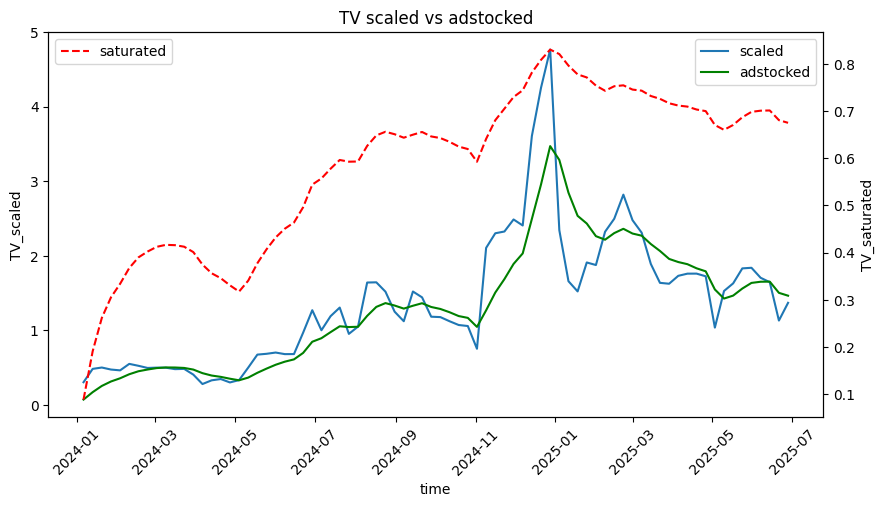

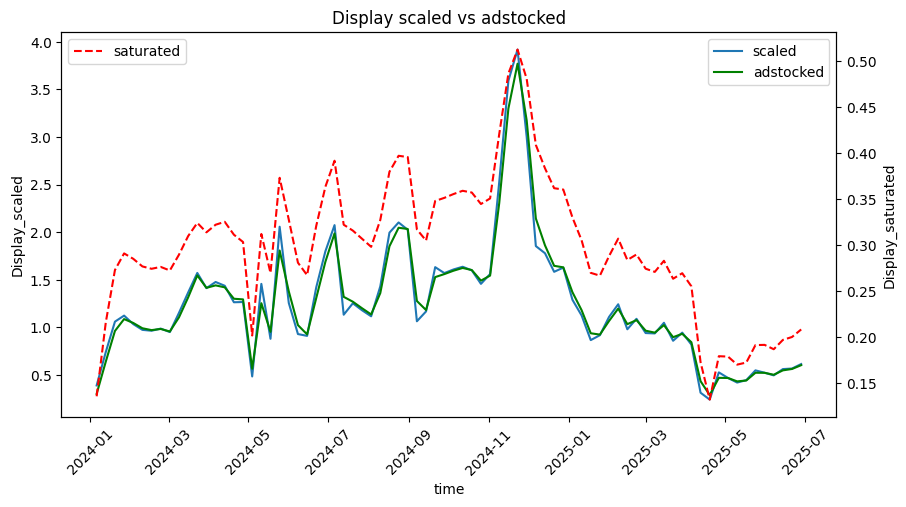

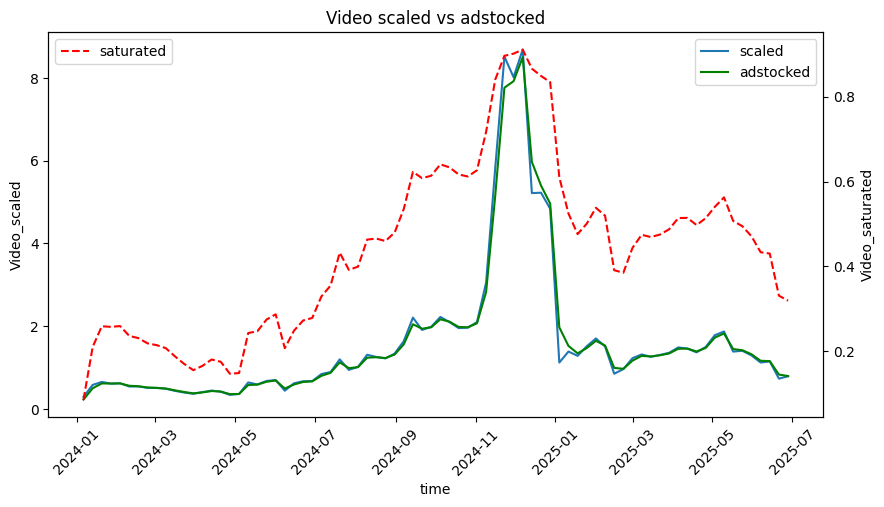

In [12]:
for chnl in media_channels:
  fig = ExportMediaTransformations.plot_media_journey(media_trans_journey_df, chnl)
  display(fig)


(30, 78, 3) (30, 78, 3) (30, 78, 3)


In [ ]:
# Load the model
mmm = model.load_mmm(f'{model_path}/{model_name}')

# Get the parameters
posterior = mmm.inference_data.posterior
alpha_m_xr = posterior.alpha_m.median(dim=['chain', 'draw'])
ec_m_xr = posterior.ec_m.median(dim=['chain', 'draw'])
slope_m_xr = posterior.slope_m.median(dim=['chain', 'draw'])

# Get the scaled media data
media_scaled = mmm.media_tensors.media_scaled


media_transformed = mmm.adstock_hill_media(
    media=media_scaled,
    alpha=tf.constant(alpha_m_xr, dtype=tf.float32),
    ec=tf.constant(ec_m_xr, dtype=tf.float32),
    slope=tf.constant(slope_m_xr, dtype=tf.float32)
)

# Create a dataframe with the transformed media data
def get_geo_weighted_media_transformed(media_transformed, weights):
  raw_media_gtm = tf.convert_to_tensor(weights, dtype=media_transformed.dtype)
  media_times_transformed_tm = tf.reduce_sum(tf.multiply(raw_media_gtm, media_transformed), axis=0)  # (time, channel)
  raw_media_sum_tm = tf.reduce_sum(raw_media_gtm, axis=0)  # (time, channel)
  return tf.math.divide_no_nan(media_times_transformed_tm, raw_media_sum_tm)

media_transformed_tm = get_geo_weighted_media_transformed(media_transformed, mmm.input_data.media)
media_transformed_tm_df = pd.DataFrame(media_transformed_tm, columns=mmm.input_data.media.media_channel.values)
media_transformed_tm_df.columns = [f'{col}_transformed' for col in media_transformed_tm_df.columns]
media_transformed_tm_df.insert(0, 'conversions', tf.reduce_mean(mmm.kpi, axis=0).numpy())
media_transformed_tm_df.insert(0, 'time', mmm.input_data.time.values)
media_transformed_tm_df.head()

,time,conversions,TV_transformed,Display_transformed,Video_transformed
0,2024-01-06,250284.90625,0.000002,0.022318,0.001163
1,2024-01-13,312974.65625,0.000005,0.027520,0.006227
2,2024-01-20,402480.87500,0.000029,0.068010,0.012024
3,2024-01-27,602656.68750,0.000161,0.130132,0.093244
4,2024-02-03,679646.68750,0.001083,0.156791,0.228473


In [5]:
# plot prior vs posterior
model_diagnostics = visualizer.ModelDiagnostics(mmm)
model_diagnostics.plot_prior_and_posterior_distribution(parameter='ec_m')

alt.FacetChart(...)

In [20]:
media_summary = visualizer.MediaSummary(mmm)
media_contribution_datset = media_summary.get_all_summary_metrics(aggregate_times=False)

/Users/mariappan.subramanian/Documents/repo/forked/meridian/meridian/analysis/analyzer.py:3121: UserWarning: Effectiveness is not reported because it does not have a clear interpretation by time period.
  warnings.warn(


In [27]:
media_contribution_datset.sel(distribution='posterior', metric='median').incremental_outcome.to_dataframe().reset_index()

,time,channel,metric,distribution,incremental_outcome
0,2024-01-06,TV,median,posterior,1.545599e+04
1,2024-01-06,Display,median,posterior,9.219741e+04
2,2024-01-06,Video,median,posterior,5.529668e+02
3,2024-01-06,All Channels,median,posterior,1.106287e+05
4,2024-01-13,TV,median,posterior,1.265851e+05
...,...,...,...,...,...
307,2025-06-21,All Channels,median,posterior,7.005518e+06
308,2025-06-28,TV,median,posterior,4.262512e+06
309,2025-06-28,Display,median,posterior,2.231345e+06
310,2025-06-28,Video,median,posterior,3.864672e+05


In [35]:
_analyzer = analyzer.Analyzer(mmm)
expected_vs_actual = _analyzer.expected_vs_actual_data()
expected_vs_actual

<xarray.Dataset> Size: 68kB
Dimensions:   (geo: 30, time: 78, metric: 3)
Coordinates:
  * metric    (metric) <U5 60B 'mean' 'ci_lo' 'ci_hi'
  * geo       (geo) <U14 2kB 'ALABAMA' 'ARIZONA' ... 'WASHINGTON' 'WISCONSIN'
  * time      (time) object 624B '2024-01-06' '2024-01-13' ... '2025-06-28'
Data variables:
    expected  (geo, time, metric) float32 28kB 2.904e+04 -2.6e+03 ... 1.379e+05
    baseline  (geo, time, metric) float32 28kB 2.879e+04 -2.87e+03 ... 3.568e+04
    actual    (geo, time) float32 9kB 4.115e+04 4.785e+04 ... 1.202e+05
Attributes:
    confidence_level:  0.9

In [ ]:
expected_outcome = _analyzer.expected_outcome(aggregate_geos=False, aggregate_times=False)
print(expected_outcome.shape)
expected_outcome[0, 0, ...]

(2, 2000, 30, 78)


<tf.Tensor: shape=(30, 78), dtype=float32, numpy=
array([[  76756.5  ,   60410.855,  103201.14 , ...,   89979.48 ,
         120752.67 ,  104580.66 ],
       [ 365179.94 ,  341266.72 ,  407627.8  , ...,  494970.72 ,
         499520.62 ,  449004.47 ],
       [1624573.2  , 1531636.6  , 1940543.8  , ..., 1854976.6  ,
        1984366.4  , 1834347.4  ],
       ...,
       [ 497270.84 ,  470766.12 ,  553842.4  , ...,  920807.4  ,
         988181.5  ,  964127.5  ],
       [ 162852.25 ,  142181.73 ,  218631.23 , ...,  363484.97 ,
         357851.   ,  303660.6  ],
       [  48212.777,   51008.02 ,  101832.94 , ...,   97609.77 ,
         122691.03 ,  113096.14 ]], dtype=float32)>

In [82]:
posterior.draw.size

2000

In [88]:
np.arange(100, step=10)

array([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

<tf.Tensor: shape=(4000,), dtype=float32, numpy=
array([0.9788204 , 1.000244  , 0.9951712 , ..., 1.0016898 , 0.99170774,
       1.0075788 ], dtype=float32)>

In [49]:
tf.reduce_mean(expected_outcome, axis=(0, 1)).numpy()

np.float32(1139561000.0)

In [51]:
input_data = mmm.input_data
tf.reduce_mean(expected_outcome, axis=(0, 1)).numpy() / input_data.kpi.sum().values


np.float64(0.999995846663313)

In [14]:
mmm.prior_broadcast.ec_m.mean()

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([1.3562803, 6.1875362, 2.247672 ], dtype=float32)>

In [12]:
mmm.prior_broadcast.ec_m.stddev()

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([0.2906473, 1.4451156, 0.5108699], dtype=float32)>

In [ ]:
# {'Display': 8.12, 'TV': 1.76, 'Video': 2.94},

In [6]:
print(alpha_m_xr.values)
print(ec_m_xr.values)
print(slope_m_xr.values)

[0.8835007  0.08201271 0.6653521 ]
[1.6379399 1.537827  2.886812 ]
[1.0157111 1.616862  2.9534266]


In [49]:
# raw media sum
raw_media = mmm.input_data.media
total_raw_imp = raw_media.sum(dim=['geo', 'media_time']).values
print(f'{total_raw_imp}, {total_raw_imp[0]/total_raw_imp[1]:.2f}, {total_raw_imp[0]/total_raw_imp[2]:.2f}')

[2.96007836e+08 9.74563174e+09 2.37141238e+08], 0.03, 1.25


In [42]:
# scaled imp
media_scaled = mmm.media_tensors.media_scaled
total_media_scaled = tf.reduce_sum(media_scaled, axis=(0, 1)).numpy()
print(total_media_scaled, total_media_scaled[0]/total_media_scaled[1], total_media_scaled[0]/total_media_scaled[2])

[2676.8408 2422.897  2963.4265] 1.10481 0.9032925


In [46]:
# media transformed
total_media_transformed = tf.reduce_sum(media_transformed, axis=(0, 1)).numpy()
print(total_media_transformed, total_media_transformed[0]/total_media_transformed[1], total_media_transformed[0]/total_media_transformed[2])

[ 12.079294 380.14343  187.02748 ] 0.031775624 0.06458566


In [47]:
media_transformed_tm

<tf.Tensor: shape=(78, 3), dtype=float32, numpy=
array([[1.72733735e-06, 2.23181173e-02, 1.16298883e-03],
       [4.68021790e-06, 2.75199581e-02, 6.22713845e-03],
       [2.94386118e-05, 6.80102557e-02, 1.20236520e-02],
       [1.60897544e-04, 1.30131781e-01, 9.32439193e-02],
       [1.08311535e-03, 1.56791359e-01, 2.28473023e-01],
       [1.87976542e-03, 1.28545195e-01, 2.40975440e-01],
       [4.20331582e-03, 1.35693550e-01, 1.95337296e-01],
       [4.99141030e-03, 1.31147042e-01, 2.26000890e-01],
       [3.13843577e-03, 1.27610400e-01, 1.56242475e-01],
       [3.15078232e-03, 1.13961175e-01, 2.06529424e-01],
       [3.81656061e-03, 1.05993666e-01, 1.81570381e-01],
       [7.02264439e-03, 1.47695690e-01, 1.80326581e-01],
       [1.21017555e-02, 1.65959299e-01, 2.46877030e-01],
       [7.61584239e-03, 1.76804781e-01, 2.53735304e-01],
       [8.39991681e-03, 2.04451069e-01, 2.46632755e-01],
       [9.45745781e-03, 2.32920229e-01, 2.66006708e-01],
       [8.88128765e-03, 2.43051633e-01,

In [24]:
ec_m_xr

<xarray.DataArray 'ec_m' (media_channel: 3)> Size: 12B
array([8.686501, 4.529402, 3.555633], dtype=float32)
Coordinates:
  * media_channel  (media_channel) object 24B 'TV' 'Display' 'Video'

In [23]:
tf.reduce_sum(tf.reduce_mean(media_transformed, axis=0), axis=0)

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([ 0.4026432, 12.67145  ,  6.2342567], dtype=float32)>

In [12]:
tf.reduce_sum(media_transformed_tm, axis=0)

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([ 0.5225531, 14.428366 ,  9.638321 ], dtype=float32)>

In [26]:
tf.reduce_sum(media_transformed, axis=(0, 1))

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([ 12.079294, 380.14343 , 187.02748 ], dtype=float32)>

In [27]:
posterior

<xarray.Dataset> Size: 5MB
Dimensions:        (chain: 2, draw: 2000, media_channel: 3, geo: 30, knots: 78,
                    time: 78)
Coordinates:
  * chain          (chain) int64 16B 0 1
  * draw           (draw) int64 16kB 0 1 2 3 4 5 ... 1995 1996 1997 1998 1999
  * media_channel  (media_channel) object 24B 'TV' 'Display' 'Video'
  * geo            (geo) <U14 2kB 'ALABAMA' 'ARIZONA' ... 'WISCONSIN'
  * knots          (knots) int64 624B 0 1 2 3 4 5 6 7 ... 71 72 73 74 75 76 77
  * time           (time) object 624B '2024-01-06' '2024-01-13' ... '2025-06-28'
Data variables:
    alpha_m        (chain, draw, media_channel) float32 48kB 0.8374 ... 0.6817
    beta_gm        (chain, draw, geo, media_channel) float32 1MB 1.866 ... 0....
    beta_m         (chain, draw, media_channel) float32 48kB 0.651 ... -1.38
    ec_m           (chain, draw, media_channel) float32 48kB 9.38 ... 3.712
    eta_m          (chain, draw, media_channel) float32 48kB -0.1179 ... -0.7863
    knot_values    (chain, draw, knots) float32 1MB -0.01758 0.2815 ... 0.1936
    mu_t           (chain, draw, time) float32 1MB -0.01758 0.2815 ... 0.1936
    sigma          (chain, draw) float32 16kB 0.396 0.3806 ... 0.3915 0.405
    slope_m        (chain, draw, media_channel) float32 48kB 2.568 ... 2.97
    tau_g          (chain, draw, geo) float32 480kB -1.173 0.06513 ... -1.096
Attributes:
    created_at:     2025-09-22T19:48:55.194824+00:00
    arviz_version:  0.22.0

In [29]:
posterior.mu_t.mean(dim=['chain', 'draw'])

<xarray.DataArray 'mu_t' (time: 78)> Size: 312B
array([-0.09480463,  0.06834994,  0.25010762,  0.6133631 ,  0.6579316 ,
        0.7739205 ,  0.799599  ,  0.57484907,  0.67927635,  0.7295103 ,
        0.44701943,  0.535123  ,  0.20166941,  0.23869322,  0.3915201 ,
        0.24996914,  0.5182841 ,  0.7822207 ,  4.272628  ,  0.9147941 ,
        0.23878251,  0.4529341 ,  0.5146041 ,  0.66529346,  0.5370647 ,
        0.74830097,  0.27277908,  0.3201866 ,  0.55906105,  0.3084034 ,
        0.34326506,  0.24501683,  0.28764793,  0.20750195,  0.07959928,
        0.16143414,  0.2361872 ,  0.27463642,  0.05613628,  0.12129444,
       -0.08329444, -0.10449196, -0.01098491, -0.2912349 , -0.30238026,
       -0.2001022 ,  0.2512588 , -0.42461556, -0.05536667, -0.01126049,
       -0.2670295 , -0.36212787, -0.3546084 , -0.2673214 , -0.19212224,
        0.07287815,  0.38504377,  0.72121483,  0.5230413 ,  0.29932168,
        0.15098879, -0.06778128, -0.13808003, -0.10664529,  0.17251126,
        0.7107657 ,  0.04774959,  0.04937994,  0.07819784,  0.21984825,
        0.19151989,  0.17721593,  0.7980644 ,  0.16208522,  0.27273196,
        0.22245227,  0.3235342 ,  0.21135025], dtype=float32)
Coordinates:
  * time     (time) object 624B '2024-01-06' '2024-01-13' ... '2025-06-28'

In [30]:
posterior.tau_g.mean(dim=['chain', 'draw'])

<xarray.DataArray 'tau_g' (geo: 30)> Size: 120B
array([-1.1313393 ,  0.11686446,  0.        , -0.48080578, -0.5109862 ,
       -0.65376693, -0.12442774,  0.1593549 , -0.31502575, -1.1170057 ,
       -0.6612127 , -0.7216037 , -0.7367609 , -0.7847846 , -0.92965424,
       -0.624768  , -0.8677125 , -0.5912686 ,  0.33441788, -0.62402046,
       -0.8545443 , -0.8312248 , -0.62055385, -1.1028289 , -0.90855616,
       -0.46968675, -0.7214327 ,  0.29281616, -0.54268634, -1.1322306 ],
      dtype=float32)
Coordinates:
  * geo      (geo) <U14 2kB 'ALABAMA' 'ARIZONA' ... 'WASHINGTON' 'WISCONSIN'

In [34]:
trace = mmm.inference_data.trace
mmm.inference_data

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> trace

In [9]:
media_transformed_tm_df['TV_transformed'].sum(), media_transformed_tm_df['Video_transformed'].sum()

(np.float32(0.52255297), np.float32(9.638321))

In [20]:
np.exp(posterior.beta_m.median(dim=['chain', 'draw']).values)

array([1.6287197 , 0.54877514, 0.24538046], dtype=float32)

In [21]:
np.exp(posterior.eta_m.median(dim=['chain', 'draw']).values)

array([0.99633   , 0.55288345, 1.0042751 ], dtype=float32)

In [113]:
def get_geo_weighted_media_transformed(media_transformed, weights):
  raw_media_gtm = tf.convert_to_tensor(weights, dtype=media_transformed.dtype)
  media_times_transformed_tm = tf.reduce_sum(tf.multiply(raw_media_gtm, media_transformed), axis=0)  # (time, channel)
  raw_media_sum_tm = tf.reduce_sum(raw_media_gtm, axis=0)  # (time, channel)
  return tf.math.divide_no_nan(media_times_transformed_tm, raw_media_sum_tm)

t1 = get_geo_weighted_media_transformed(media_transformed, mmm.input_data.media)

In [110]:
weights_gtm = tf.convert_to_tensor(mmm.input_data.media, dtype=media_transformed.dtype)
weights_tm = tf.reduce_sum(weights_gtm, axis=0)  # (time, channel)
weights = tf.math.divide_no_nan(weights_gtm, weights_tm[tf.newaxis, ...])
t2 = tf.reduce_sum(media_transformed * weights, axis=0)

In [114]:
import numpy as np
np.allclose(t2, t1)

True

In [93]:
weighted_min = tf.reduce_min(geo_weighted_media_transformed_tm, axis=0)
weighted_max = tf.reduce_max(geo_weighted_media_transformed_tm, axis=0)
weighted_mean = tf.reduce_mean(geo_weighted_media_transformed_tm, axis=0)

In [96]:
actual_min = tf.reduce_min(media_transformed, axis=[0,1])
actual_max = tf.reduce_max(media_transformed, axis=[0,1])
actual_mean = tf.reduce_mean(media_transformed, axis=[0,1])

In [97]:
weighted_min / actual_min, weighted_max / actual_max, weighted_mean / actual_mean

(<tf.Tensor: shape=(3,), dtype=float32, numpy=array([      inf, 229.11852,       inf], dtype=float32)>,
 <tf.Tensor: shape=(3,), dtype=float32, numpy=array([0.16077676, 0.6424996 , 0.3581179 ], dtype=float32)>,
 <tf.Tensor: shape=(3,), dtype=float32, numpy=array([1.297807 , 1.1386517, 1.5460274], dtype=float32)>)

In [103]:
simpled_mean_data = tf.reduce_mean(media_transformed, axis=0)
simple_min = tf.reduce_min(simpled_mean_data, axis=0)
simple_max = tf.reduce_max(simpled_mean_data, axis=0)
simple_mean = tf.reduce_mean(simpled_mean_data, axis=0)
simple_min / actual_min, simple_max / actual_max, simple_mean / actual_mean

(<tf.Tensor: shape=(3,), dtype=float32, numpy=array([      inf, 108.47624,       inf], dtype=float32)>,
 <tf.Tensor: shape=(3,), dtype=float32, numpy=array([0.11220121, 0.5761005 , 0.2527024 ], dtype=float32)>,
 <tf.Tensor: shape=(3,), dtype=float32, numpy=array([1.0000002, 1.0000002, 1.0000012], dtype=float32)>)

In [101]:
weighted_min

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([1.7273373e-06, 2.2318117e-02, 1.1629888e-03], dtype=float32)>

In [100]:
actual_min

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([0.0000000e+00, 9.7408614e-05, 0.0000000e+00], dtype=float32)>

In [ ]:
raw_media_tm = mmm.input_data.media.mean(dim=['geo']).to_dataframe().reset_index()
raw_media_tm.pivot(index='media_time', columns=['media_channel'], values='media').reset_index()

media_channel,media_time,Display,TV,Video
0,2024-01-06,2.415732e+05,2061.300000,11772.666667
1,2024-01-13,4.822178e+05,15291.166667,31166.800000
2,2024-01-20,1.406717e+06,50224.900000,54692.666667
3,2024-01-27,2.813946e+06,85577.333333,209463.633333
4,2024-02-03,3.138818e+06,153839.000000,267862.900000
...,...,...,...,...
73,2025-05-31,3.931484e+06,146077.233333,88306.500000
74,2025-06-07,3.904415e+06,136132.533333,56074.733333
75,2025-06-14,4.310601e+06,199681.300000,83104.766667
76,2025-06-21,4.074910e+06,126962.533333,73037.700000


In [68]:
print(alpha_m_xr.values)
print(ec_m_xr.values)
print(slope_m_xr.values)

[0.72347814 0.07301455 0.6682159 ]
[8.686501 4.529402 3.555633]
[2.865488  1.0787537 2.933557 ]


In [18]:
media_transformed

<tf.Tensor: shape=(30, 78, 3), dtype=float32, numpy=
array([[[1.5483366e-11, 5.1751127e-03, 4.1393944e-10],
        [1.8245455e-09, 4.5414101e-03, 6.3523464e-10],
        [1.1989061e-06, 2.8501460e-02, 8.1265655e-10],
        ...,
        [3.4059659e-03, 1.7039146e-01, 8.0218157e-03],
        [8.2728742e-03, 2.0073912e-01, 4.0151365e-02],
        [1.8798398e-02, 1.4712183e-01, 2.5359768e-02]],

       [[0.0000000e+00, 5.9326580e-03, 0.0000000e+00],
        [4.6022132e-19, 1.3359657e-02, 6.0727472e-15],
        [5.6985573e-07, 4.0189166e-02, 1.6344522e-04],
        ...,
        [9.8418761e-03, 1.8666740e-01, 5.1097501e-02],
        [6.8594818e-03, 1.5455171e-01, 4.2973027e-02],
        [4.4323299e-03, 1.5749143e-01, 1.4781122e-02]],

       [[0.0000000e+00, 1.1577075e-02, 3.7290067e-07],
        [5.8370961e-07, 2.8951243e-02, 4.9129481e-05],
        [2.2125108e-05, 9.2198245e-02, 8.1922690e-04],
        ...,
        [3.9007852e-03, 2.3098129e-01, 2.4117962e-02],
        [3.7127044e-03, 

In [67]:
posterior

<xarray.Dataset> Size: 5MB
Dimensions:        (chain: 2, draw: 2000, media_channel: 3, geo: 30, knots: 78,
                    time: 78)
Coordinates:
  * chain          (chain) int64 16B 0 1
  * draw           (draw) int64 16kB 0 1 2 3 4 5 ... 1995 1996 1997 1998 1999
  * media_channel  (media_channel) object 24B 'TV' 'Display' 'Video'
  * geo            (geo) <U14 2kB 'ALABAMA' 'ARIZONA' ... 'WISCONSIN'
  * knots          (knots) int64 624B 0 1 2 3 4 5 6 7 ... 71 72 73 74 75 76 77
  * time           (time) object 624B '2024-01-06' '2024-01-13' ... '2025-06-28'
Data variables:
    alpha_m        (chain, draw, media_channel) float32 48kB 0.8374 ... 0.6817
    beta_gm        (chain, draw, geo, media_channel) float32 1MB 1.866 ... 0....
    beta_m         (chain, draw, media_channel) float32 48kB 0.651 ... -1.38
    ec_m           (chain, draw, media_channel) float32 48kB 9.38 ... 3.712
    eta_m          (chain, draw, media_channel) float32 48kB -0.1179 ... -0.7863
    knot_values    (chain, draw, knots) float32 1MB -0.01758 0.2815 ... 0.1936
    mu_t           (chain, draw, time) float32 1MB -0.01758 0.2815 ... 0.1936
    sigma          (chain, draw) float32 16kB 0.396 0.3806 ... 0.3915 0.405
    slope_m        (chain, draw, media_channel) float32 48kB 2.568 ... 2.97
    tau_g          (chain, draw, geo) float32 480kB -1.173 0.06513 ... -1.096
Attributes:
    created_at:     2025-09-22T19:48:55.194824+00:00
    arviz_version:  0.22.0

In [2]:
import numpy as np

ec50_multiplier_config = {'ALDI_US_Starcom': {'Display': 3.71, 'TV': 0.71, 'Video': 1.43},
 'Allergan': {'Display': 4.81, 'TV': 1.3, 'Video': 2.5},
 'Audi': {'Display': 5.42, 'TV': 1.5, 'Video': 2.78},
 'Burger_King': {'Display': 3.02, 'TV': 0.81, 'Video': 3.33},
 'Chick-Fil-A': {'Display': np.nan, 'TV': 0.97, 'Video': 3.85},
 'Chumba_Casino': {'Display': 1.53, 'TV': 0.37, 'Video': 0.52},
 'Huntington_National_Bank': {'Display': 11.82, 'TV': 1.36, 'Video': 2.7},
 'Hyundai': {'Display': 6.19, 'TV': 1.0, 'Video': 2.17},
 'IBM_-_US': {'Display': 8.12, 'TV': 1.02, 'Video': 1.22},
 'Intuit_-_Quickbooks': {'Display': 10.83, 'TV': 1.2, 'Video': 5.0},
 'Live_Nation_MasterAdvertiser': {'Display': 8.12, 'TV': 1.76, 'Video': 2.94},
 'MRG_Chevy_LMA': {'Display': 2.83, 'TV': 0.53, 'Video': 1.56},
 'Mattress_Firm_US_Mediavest': {'Display': np.nan, 'TV': 1.11, 'Video': 2.0},
 'Mazda': {'Display': 5.65, 'TV': 1.15, 'Video': 3.57},
 'Meijer': {'Display': 8.67, 'TV': 0.88, 'Video': 5.0},
 'Popeyes': {'Display': 3.25, 'TV': 1.5, 'Video': 3.12},
 'Progressive_Insurance': {'Display': 1.81, 'TV': 0.6, 'Video': 0.94},
 'Samsung_US_Starcom': {'Display': 9.29, 'TV': 1.2, 'Video': 2.63}
 }

In [8]:
import pandas as pd
pd.DataFrame.from_dict(ec50_multiplier_config, orient='index')

,Display,TV,Video
ALDI_US_Starcom,3.71,0.71,1.43
Allergan,4.81,1.30,2.50
Audi,5.42,1.50,2.78
Burger_King,3.02,0.81,3.33
Chick-Fil-A,NaN,0.97,3.85
Chumba_Casino,1.53,0.37,0.52
Huntington_National_Bank,11.82,1.36,2.70
Hyundai,6.19,1.00,2.17
IBM_-_US,8.12,1.02,1.22
Intuit_-_Quickbooks,10.83,1.20,5.00
